<a href="https://colab.research.google.com/github/christinengalle19-collab/Assignement2New/blob/main/TVC_22_financial_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Ce projet consiste à analyser les données financières réelles de la chaîne de télévision TVC22 afin de développer un modèle de prédiction financière basé sur ses rapports annuels.

## Dans un premier temps, nous allons calculer la proportion de chaque catégorie de charges par rapport au revenu total, ce qui permettra de comprendre précisément où va l’argent et d’identifier les postes les plus coûteux.

## Dans un second temps, nous construirons un modèle de prédiction capable d’estimer les résultats financiers futurs de l’entreprise. Ce modèle aidera TVC22 à anticiper ses performances, optimiser sa gestion budgétaire et soutenir la prise de décision stratégique.


In [ ]:
#import library
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.tree import DecisionTreeClassifier as dt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import tkinter as tk
from tkinter import ttk
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg






In [ ]:
#import Excel data
df = pd.read_excel('TVC22_DATA_2016-2026-Cleaned.xlsx')

In [ ]:
#Displays first rows
print(df.head())

   ANNEES R1_BINGO/NEVADA  R2_SUBVENTION_VIDEOTRON  R3_AUTRES REVENUS  \
0    2016           69158                  92938.0            48045.0   
1    2017           65695                  97500.0            68969.0   
2    2018           63414                 108000.0            86358.0   
3    2019           85541                 121955.0            99150.0   
4    2020           99936                 119224.0           112324.0   

   R4_Subvention salariale  R5_Gain_dispo  CH1_ASSURANCE  \
0                      0.0              0         2489.0   
1                      0.0              0         7037.0   
2                      0.0              0         5401.0   
3                      0.0              0         6072.0   
4                      0.0              0         7857.0   

  CH2_BIEN_ETRE_BENEVOLES CH3_DEPENSES_BINGO CH4_EMISSION  ...  \
0                    1145              62648         5246  ...   
1                    1150              60946         9977  ...   
2 

In [ ]:
df.dtypes

,0
ANNEES,int64
R1_BINGO/NEVADA,object
R2_SUBVENTION_VIDEOTRON,float64
R3_AUTRES REVENUS,float64
R4_Subvention salariale,float64
R5_Gain_dispo,int64
CH1_ASSURANCE,float64
CH2_BIEN_ETRE_BENEVOLES,object
CH3_DEPENSES_BINGO,object
CH4_EMISSION,object


In [ ]:
#Shape
print(df.shape)

(11, 26)


In [ ]:
#check for missing values
print(df.isnull().sum())

ANNEES                             0
R1_BINGO/NEVADA                    0
R2_SUBVENTION_VIDEOTRON            0
R3_AUTRES REVENUS                  0
R4_Subvention salariale            1
R5_Gain_dispo                      0
CH1_ASSURANCE                      0
CH2_BIEN_ETRE_BENEVOLES            0
CH3_DEPENSES_BINGO                 0
CH4_EMISSION                       0
CH5_ENTRETIEN_REPARATION           0
CH6_FOURNITURE_CASSETTES           0
CH7_FRAIS_BUREAU                   0
CH8_FRAIS_DEPLACEMENT              0
CH9_HONORAIRES_PROFESSIONNELS      0
CH10_LOYER                         0
CH11_PUBLICITE_PROMOTIONS          0
CH12_SALAIRES_AVANTAGES_SOCIAUX    0
CH13_SOUS_TRAITANTS                0
CH14_TAXES_AFFAIRES                0
CH15_TELECOMMUNICATIONS            0
CH16_AMORTISSEMENTS_IMMO_COP       0
CH17_FRAIS_BANCAIRES               0
CH18_INTERETS_DELT                 0
CH19_PETITS_EQUIP                  1
CH20_PERTES_DISPO_IMMO             0
dtype: int64


In [ ]:
#Handling missing values
df['R4_Subvention salariale']= df['R4_Subvention salariale'].fillna(0)
df['CH19_PETITS_EQUIP']= df['CH19_PETITS_EQUIP'].fillna(0)

In [ ]:
df.columns

Index(['ANNEES', 'R1_BINGO/NEVADA', 'R2_SUBVENTION_VIDEOTRON',
       'R3_AUTRES REVENUS', 'R4_Subvention salariale', 'R5_Gain_dispo',
       'CH1_ASSURANCE', 'CH2_BIEN_ETRE_BENEVOLES', 'CH3_DEPENSES_BINGO',
       'CH4_EMISSION', 'CH5_ENTRETIEN_REPARATION', 'CH6_FOURNITURE_CASSETTES',
       'CH7_FRAIS_BUREAU', 'CH8_FRAIS_DEPLACEMENT',
       'CH9_HONORAIRES_PROFESSIONNELS', 'CH10_LOYER',
       'CH11_PUBLICITE_PROMOTIONS', 'CH12_SALAIRES_AVANTAGES_SOCIAUX',
       'CH13_SOUS_TRAITANTS', 'CH14_TAXES_AFFAIRES', 'CH15_TELECOMMUNICATIONS',
       'CH16_AMORTISSEMENTS_IMMO_COP', 'CH17_FRAIS_BANCAIRES',
       'CH18_INTERETS_DELT', 'CH19_PETITS_EQUIP', 'CH20_PERTES_DISPO_IMMO'],
      dtype='object')

In [ ]:
#Handling non-numeric values and missing values
# Identify object columns that should be numeric
object_cols = df.select_dtypes(include='object').columns

for col in object_cols:
    # Replace common non-numeric strings (like '-', ' - ', etc.) with NaN using a regex
    df[col] = df[col].replace(r'^\s*-\s*$', np.nan, regex=True)

    # Convert to numeric, coercing any other errors to NaN
    df[col] = pd.to_numeric(df[col], errors='coerce')

    # Fill any NaN values (either original NaN or those from replacement/coercion) with 0
    df[col] = df[col].fillna(0)

/tmp/ipykernel_1641/3144163802.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace(r'^\s*-\s*$', np.nan, regex=True)


In [ ]:
#summary statisques
print(df.describe())

            ANNEES  R1_BINGO/NEVADA  R2_SUBVENTION_VIDEOTRON  \
count    11.000000        11.000000                11.000000   
mean   2021.000000     56554.363636            122928.450909   
std       3.316625     42781.367711             28925.582958   
min    2016.000000         0.000000             88505.000000   
25%    2018.500000     24468.000000            102750.000000   
50%    2021.000000     63414.000000            119224.000000   
75%    2023.500000     77349.500000            133627.500000   
max    2026.000000    131628.000000            176590.000000   

       R3_AUTRES REVENUS  R4_Subvention salariale  R5_Gain_dispo  \
count          11.000000                 11.00000      11.000000   
mean        99662.168182              23116.00000     934.727273   
std         87732.490378              51655.69002    3100.139645   
min          3466.000000                  0.00000       0.000000   
25%         52394.000000                  0.00000       0.000000   
50%         689

In [ ]:
#encoding variables
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()



In [ ]:
#scales features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)
df_scaled = pd.DataFrame(df_scaled, columns=df.columns)

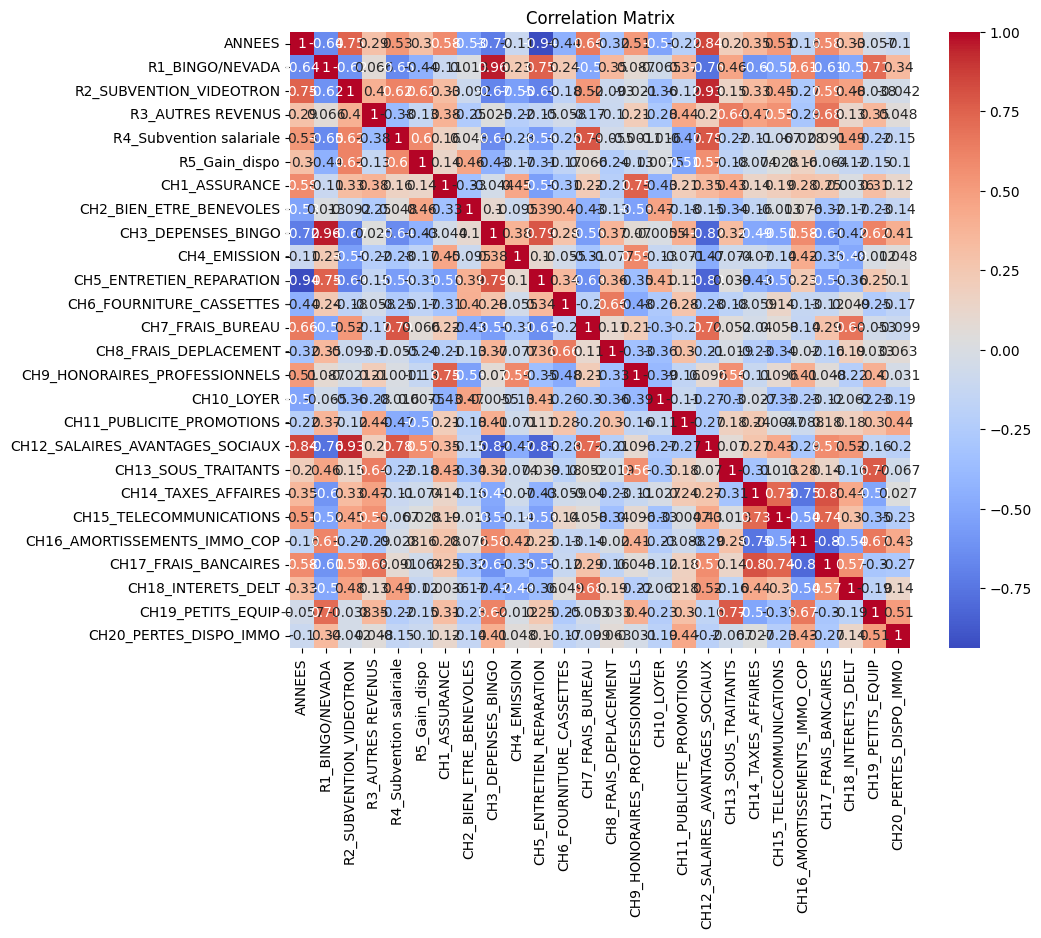

In [ ]:
#relation between variables
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

## La subvention Bingo et les depenses bingo sont de 0.96, ce qui implique que pres de 96% de cette subvention vont dans les depenses Bingo

##La relation entre le salaire et la subvention videotron est de 0.93, ce qui veut dit pres de 93% des subventions videotron vont dans les salaires

In [ ]:
#Create Total income column
df['Total_Income'] = df[['R3_AUTRES REVENUS', 'R1_BINGO/NEVADA', 'R2_SUBVENTION_VIDEOTRON','R4_Subvention salariale','R5_Gain_dispo']].sum(axis=1)

In [ ]:
#Create Total expenses
df['Total_Expenses'] = df[['CH1_ASSURANCE','CH2_BIEN_ETRE_BENEVOLES',
       'CH3_DEPENSES_BINGO', 'CH4_EMISSION', 'CH5_ENTRETIEN_REPARATION',
       'CH6_FOURNITURE_CASSETTES', 'CH7_FRAIS_BUREAU', 'CH8_FRAIS_DEPLACEMENT',
       'CH9_HONORAIRES_PROFESSIONNELS', 'CH10_LOYER',
       'CH11_PUBLICITE_PROMOTIONS', 'CH12_SALAIRES_AVANTAGES_SOCIAUX',
       'CH13_SOUS_TRAITANTS', 'CH14_TAXES_AFFAIRES', 'CH15_TELECOMMUNICATIONS',
       'CH16_AMORTISSEMENTS_IMMO_COP', 'CH17_FRAIS_BANCAIRES',
       'CH18_INTERETS_DELT', 'CH19_PETITS_EQUIP', 'CH20_PERTES_DISPO_IMMO' ]].sum(axis=1)

In [ ]:
#Create total expenses per category per year
expense_cols_year=['ANNEES', 'CH1_ASSURANCE', 'CH2_BIEN_ETRE_BENEVOLES',
       'CH3_DEPENSES_BINGO', 'CH4_EMISSION', 'CH5_ENTRETIEN_REPARATION',
       'CH6_FOURNITURE_CASSETTES', 'CH7_FRAIS_BUREAU', 'CH8_FRAIS_DEPLACEMENT',
       'CH9_HONORAIRES_PROFESSIONNELS', 'CH10_LOYER',
       'CH11_PUBLICITE_PROMOTIONS', 'CH12_SALAIRES_AVANTAGES_SOCIAUX',
       'CH13_SOUS_TRAITANTS', 'CH14_TAXES_AFFAIRES', 'CH15_TELECOMMUNICATIONS',
       'CH16_AMORTISSEMENTS_IMMO_COP', 'CH17_FRAIS_BANCAIRES',
       'CH18_INTERETS_DELT', 'CH19_PETITS_EQUIP', 'CH20_PERTES_DISPO_IMMO']
total_expenses = df[expense_cols_year].groupby('ANNEES').sum()
print(total_expenses)

        CH1_ASSURANCE  CH2_BIEN_ETRE_BENEVOLES  CH3_DEPENSES_BINGO  \
ANNEES                                                               
2016          2489.00                   1145.0             62648.0   
2017          7037.00                   1150.0             60946.0   
2018          5401.00                   2131.0             57196.0   
2019          6072.00                    580.0             73775.0   
2020          7857.00                    412.0             92534.0   
2021          8838.00                    357.0             94664.0   
2022         10502.00                    417.0             64255.0   
2023          4972.00                      0.0             18724.0   
2024          8030.00                   1727.0               123.0   
2025          7608.00                      0.0                 0.0   
2026          8947.32                      0.0                 0.0   

        CH4_EMISSION  CH5_ENTRETIEN_REPARATION  CH6_FOURNITURE_CASSETTES  \
ANNEES       

In [ ]:
# Total expensis per category for the 10 past years
expense_cols = [col for col in df.columns if col.startswith("CH")]
total_expenses = df[expense_cols].sum().sort_values(ascending=False)
total_expenses

,0
CH12_SALAIRES_AVANTAGES_SOCIAUX,1835194.63
CH3_DEPENSES_BINGO,524865.00
CH16_AMORTISSEMENTS_IMMO_COP,177380.00
CH13_SOUS_TRAITANTS,141672.93
CH4_EMISSION,100401.00
CH9_HONORAIRES_PROFESSIONNELS,94862.58
CH7_FRAIS_BUREAU,85037.39
CH1_ASSURANCE,77753.32
CH11_PUBLICITE_PROMOTIONS,63831.52
CH15_TELECOMMUNICATIONS,61430.00


<Axes: >

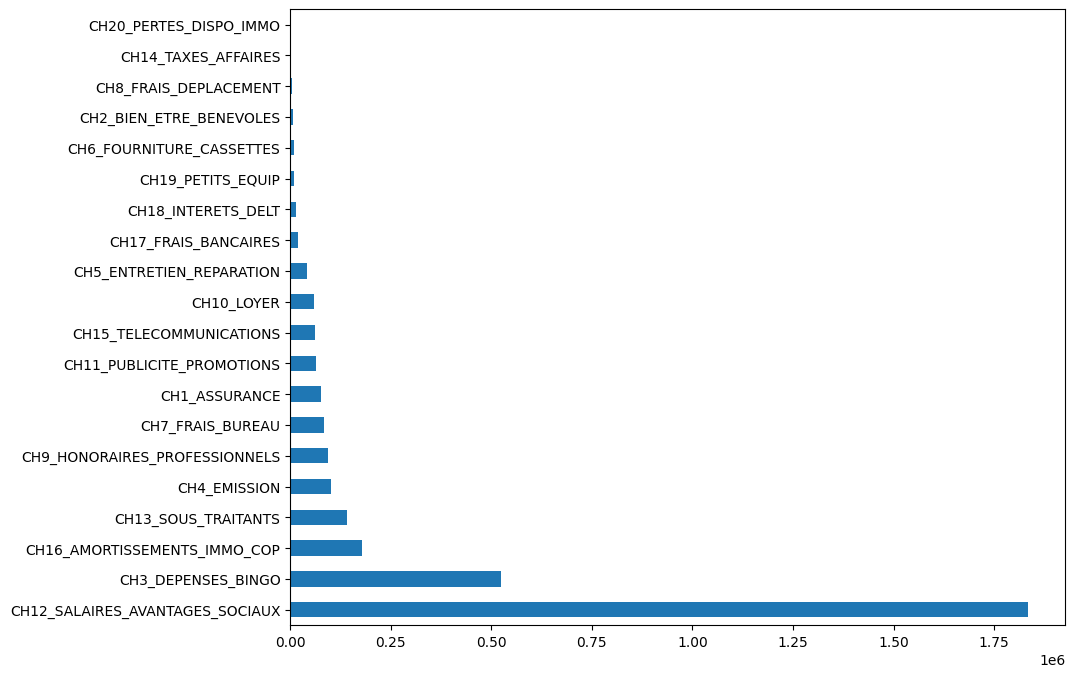

In [ ]:
total_expenses.plot(kind="barh", figsize=(10,8))


In [ ]:
#expenses percentage per year
total_expenses_percentage = total_expenses.div(total_expenses.sum(axis=1), axis=0) * 100
print(total_expenses_percentage)


        CH1_ASSURANCE  CH2_BIEN_ETRE_BENEVOLES  CH3_DEPENSES_BINGO  \
ANNEES                                                               
2016         1.255239                 0.577440           31.594289   
2017         2.966157                 0.484735           25.689272   
2018         2.031398                 0.801501           21.512284   
2019         2.111596                 0.201701           25.655961   
2020         2.508292                 0.131528           29.540833   
2021         2.183694                 0.088208           23.389593   
2022         3.485204                 0.138386           21.323727   
2023         1.997445                 0.000000            7.522156   
2024         2.220489                 0.477557            0.034012   
2025         2.074172                 0.000000            0.000000   
2026         2.573561                 0.000000            0.000000   

        CH4_EMISSION  CH5_ENTRETIEN_REPARATION  CH6_FOURNITURE_CASSETTES  \
ANNEES       

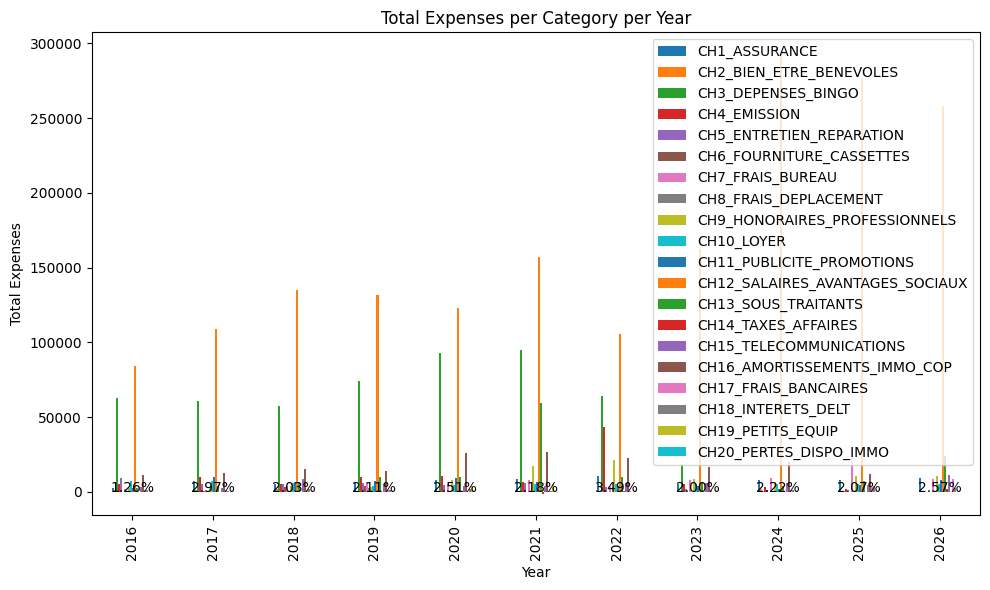

In [ ]:
total_expenses.plot(kind='bar', figsize=(10, 6))
plt.xlabel('Year')
plt.ylabel('Total Expenses')
plt.title('Total Expenses per Category per Year')
plt.legend(loc='upper right')


# Ajouter les pourcentages sur les barres
for i, value in enumerate(total_expenses_percentage.iloc[:, 0]): # Using iloc[:, 0] to get the first column of the dataframe for iteration
    plt.text(i, value + 0.5, f"{value:.2f}%", ha='center', fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
#Create the colum profit
df['Profit'] = df['Total_Income'] - df['Total_Expenses']

In [ ]:
df

,ANNEES,R1_BINGO/NEVADA,R2_SUBVENTION_VIDEOTRON,R3_AUTRES REVENUS,R4_Subvention salariale,R5_Gain_dispo,CH1_ASSURANCE,CH2_BIEN_ETRE_BENEVOLES,CH3_DEPENSES_BINGO,CH4_EMISSION,...,CH14_TAXES_AFFAIRES,CH15_TELECOMMUNICATIONS,CH16_AMORTISSEMENTS_IMMO_COP,CH17_FRAIS_BANCAIRES,CH18_INTERETS_DELT,CH19_PETITS_EQUIP,CH20_PERTES_DISPO_IMMO,Total_Income,Total_Expenses,Profit
0,2016,69158.0,92938.00,48045.00,0.0,0,2489.00,1145.0,62648.0,5246.0,...,75.00,3470,10920.0,930.00,1255.00,0.0,0.0,210141.00,198289.00,11852.00
1,2017,65695.0,97500.00,68969.00,0.0,0,7037.00,1150.0,60946.0,9977.0,...,175.00,2578,12780.0,1375.00,772.00,0.0,0.0,232164.00,237243.00,-5079.00
2,2018,63414.0,108000.00,86358.00,0.0,0,5401.00,2131.0,57196.0,4984.0,...,175.00,8781,15146.0,1305.00,1716.00,0.0,0.0,257772.00,265876.00,-8104.00
3,2019,85541.0,121955.00,99150.00,0.0,0,6072.00,580.0,73775.0,9917.0,...,0.00,5110,14043.0,1433.00,1385.00,0.0,0.0,306646.00,287555.00,19091.00
4,2020,99936.0,119224.00,112324.00,0.0,0,7857.00,412.0,92534.0,10818.0,...,220.00,3784,26109.0,-99.00,1838.00,3686.0,543.0,331484.00,313241.00,18243.00
5,2021,131628.0,122742.00,198785.00,0.0,0,8838.00,357.0,94664.0,6430.0,...,-1164.00,3642,26921.0,762.00,274.00,5372.0,0.0,453155.00,404727.00,48428.00
6,2022,57790.0,88505.00,56743.00,0.0,0,10502.00,417.0,64255.0,43080.0,...,286.00,5956,22748.0,765.00,0.00,167.0,0.0,203038.00,301331.00,-98293.00
7,2023,48936.0,113090.00,41046.00,0.0,0,4972.00,0.0,18724.0,5130.0,...,0.00,6090,16672.0,899.00,0.00,0.0,0.0,203072.00,248918.00,-45846.00
8,2024,0.0,176590.00,64023.00,116349.0,10282,8030.00,1727.0,123.0,3233.0,...,0.00,5804,19959.0,1405.00,901.00,0.0,0.0,367244.00,361632.00,5612.00
9,2025,0.0,144513.00,3466.00,137927.0,0,7608.00,0.0,0.0,1586.0,...,0.00,4749,12082.0,3083.00,3899.00,0.0,0.0,285906.00,366797.00,-80891.00


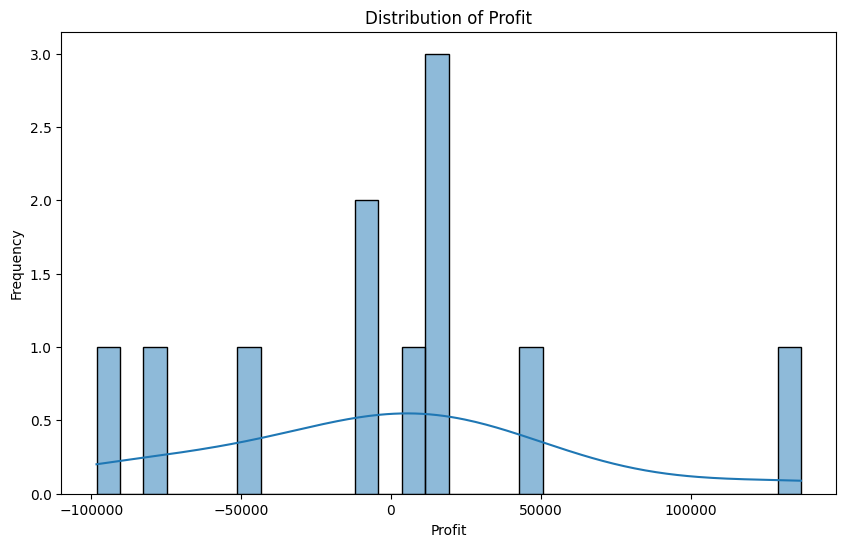

In [ ]:
#displays the profit
plt.figure(figsize=(10, 6))
sns.histplot(df['Profit'], bins=30, kde=True)
plt.xlabel('Profit')
plt.ylabel('Frequency')
plt.title('Distribution of Profit')
plt.show()

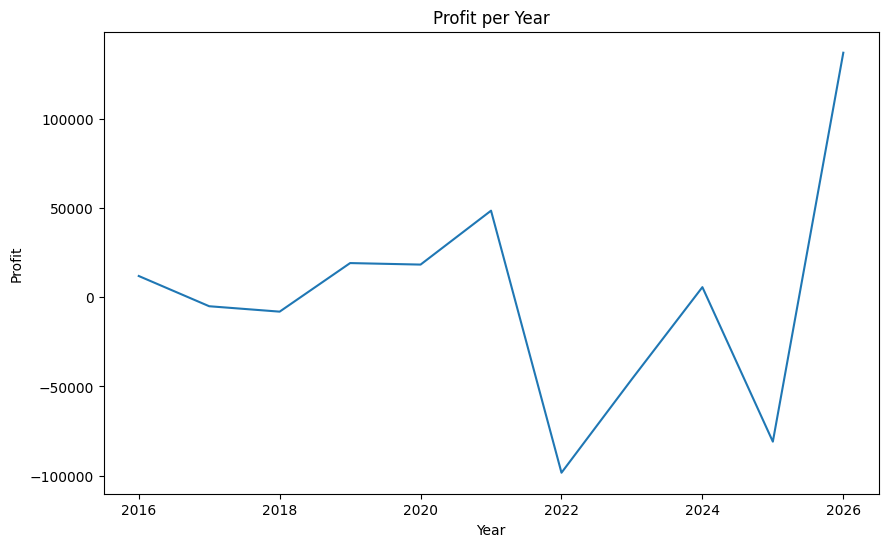

In [ ]:
#displays profit per year
plt.figure(figsize=(10, 6))
plt.plot(df['ANNEES'], df['Profit'])
plt.xlabel('Year')
plt.ylabel('Profit')
plt.title('Profit per Year')
plt.show()

In [ ]:
#split the dataset into ten represent the year
df_16 = df[df['ANNEES'] == 2016]
df_17 = df[df['ANNEES'] == 2017]
df_18 = df[df['ANNEES'] == 2018]
df_19 = df[df['ANNEES'] == 2019]
df_20 = df[df['ANNEES'] == 2020]
df_21 = df[df['ANNEES'] == 2021]
df_22 = df[df['ANNEES'] == 2022]
df_23 = df[df['ANNEES'] == 2023]
df_24 = df[df['ANNEES'] == 2024]
df_25 = df[df['ANNEES'] == 2025]
df_26 = df[df['ANNEES'] == 2026]




In [ ]:
#represent the 2025 expenses by percentage
# Calcul du pourcentage per category
total_expenses_2025 = df_25[expense_cols_year].sum()
total_expenses_percentage_2025 = total_expenses_2025 / total_expenses_2025.sum() * 100

print(total_expenses_percentage_2025)


ANNEES                              0.549045
CH1_ASSURANCE                       2.062784
CH2_BIEN_ETRE_BENEVOLES             0.000000
CH3_DEPENSES_BINGO                  0.000000
CH4_EMISSION                        0.430018
CH5_ENTRETIEN_REPARATION            0.018979
CH6_FOURNITURE_CASSETTES            0.000000
CH7_FRAIS_BUREAU                    7.729745
CH8_FRAIS_DEPLACEMENT               0.215822
CH9_HONORAIRES_PROFESSIONNELS       2.883234
CH10_LOYER                          1.450564
CH11_PUBLICITE_PROMOTIONS           1.232302
CH12_SALAIRES_AVANTAGES_SOCIAUX    75.034570
CH13_SOUS_TRAITANTS                 1.936435
CH14_TAXES_AFFAIRES                 0.000000
CH15_TELECOMMUNICATIONS             1.287613
CH16_AMORTISSEMENTS_IMMO_COP        3.275835
CH17_FRAIS_BANCAIRES                0.835905
CH18_INTERETS_DELT                  1.057150
CH19_PETITS_EQUIP                   0.000000
CH20_PERTES_DISPO_IMMO              0.000000
dtype: float64


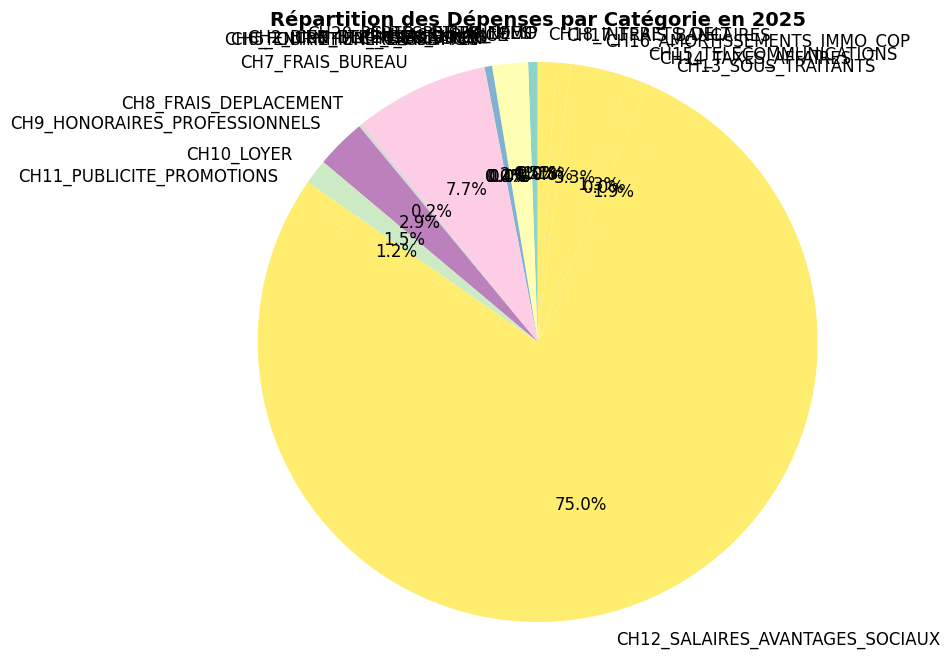

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

# Couleurs plus harmonieuses
colors = plt.cm.Set3(range(len(total_expenses_percentage_2025)))

plt.pie(
    total_expenses_percentage_2025,
    labels=total_expenses_percentage_2025.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    textprops={'fontsize': 12}
)

plt.title('Répartition des Dépenses par Catégorie en 2025', fontsize=14, fontweight='bold')

# Assurer que le pie chart est bien rond
plt.axis('equal')

plt.show()

In [ ]:
#represent the 2024 expenses by percentage
# Calcul du pourcentage per category
total_expenses_2024 = df_24[expense_cols_year].sum()
total_expenses_percentage_2024 = total_expenses_2024 / total_expenses_2024.sum() * 100

print(total_expenses_percentage_2024)


ANNEES                              0.556570
CH1_ASSURANCE                       2.208131
CH2_BIEN_ETRE_BENEVOLES             0.474899
CH3_DEPENSES_BINGO                  0.033823
CH4_EMISSION                        0.889027
CH5_ENTRETIEN_REPARATION            0.323108
CH6_FOURNITURE_CASSETTES            0.000000
CH7_FRAIS_BUREAU                    2.529313
CH8_FRAIS_DEPLACEMENT               0.000000
CH9_HONORAIRES_PROFESSIONNELS       1.707933
CH10_LOYER                          1.499219
CH11_PUBLICITE_PROMOTIONS           0.489474
CH12_SALAIRES_AVANTAGES_SOCIAUX    80.477979
CH13_SOUS_TRAITANTS                 1.091966
CH14_TAXES_AFFAIRES                 0.000000
CH15_TELECOMMUNICATIONS             1.596014
CH16_AMORTISSEMENTS_IMMO_COP        5.488429
CH17_FRAIS_BANCAIRES                0.386354
CH18_INTERETS_DELT                  0.247762
CH19_PETITS_EQUIP                   0.000000
CH20_PERTES_DISPO_IMMO              0.000000
dtype: float64


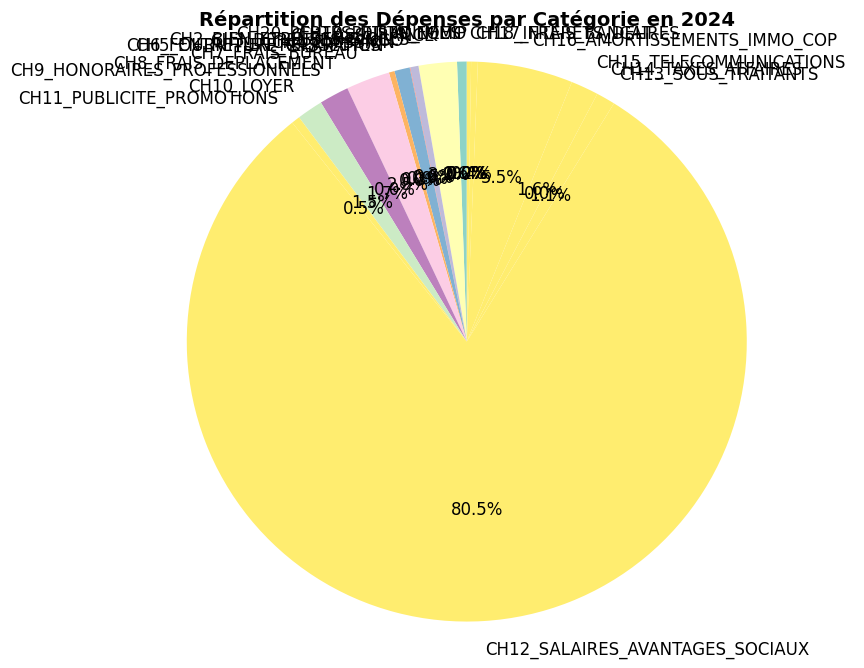

In [ ]:
# Pie chart of 2024 total expenses
plt.figure(figsize=(10, 8))

# Couleurs plus harmonieuses
colors = plt.cm.Set3(range(len(total_expenses_percentage_2024)))

plt.pie(
    total_expenses_percentage_2024, labels=total_expenses_percentage_2024.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    textprops={'fontsize': 12}
)

plt.title('Répartition des Dépenses par Catégorie en 2024', fontsize=14, fontweight='bold')

# Assurer que le pie chart est bien rond
plt.axis('equal')

plt.show()

In [ ]:
#represent the 2024 expenses by percentage
# Calcul du pourcentage per category
total_expenses_2026 = df_26[expense_cols_year].sum()
total_expenses_percentage_2026 = total_expenses_2026 / total_expenses_2026.sum() * 100

print(total_expenses_percentage_2026)

ANNEES                              0.579372
CH1_ASSURANCE                       2.558650
CH2_BIEN_ETRE_BENEVOLES             0.000000
CH3_DEPENSES_BINGO                  0.000000
CH4_EMISSION                        0.000000
CH5_ENTRETIEN_REPARATION            0.000000
CH6_FOURNITURE_CASSETTES            0.000000
CH7_FRAIS_BUREAU                    2.493755
CH8_FRAIS_DEPLACEMENT               0.000000
CH9_HONORAIRES_PROFESSIONNELS       2.969661
CH10_LOYER                          1.423670
CH11_PUBLICITE_PROMOTIONS           2.262158
CH12_SALAIRES_AVANTAGES_SOCIAUX    73.820327
CH13_SOUS_TRAITANTS                 6.752264
CH14_TAXES_AFFAIRES                 0.575177
CH15_TELECOMMUNICATIONS             3.278913
CH16_AMORTISSEMENTS_IMMO_COP        0.000000
CH17_FRAIS_BANCAIRES                2.493755
CH18_INTERETS_DELT                  0.792298
CH19_PETITS_EQUIP                   0.000000
CH20_PERTES_DISPO_IMMO              0.000000
dtype: float64


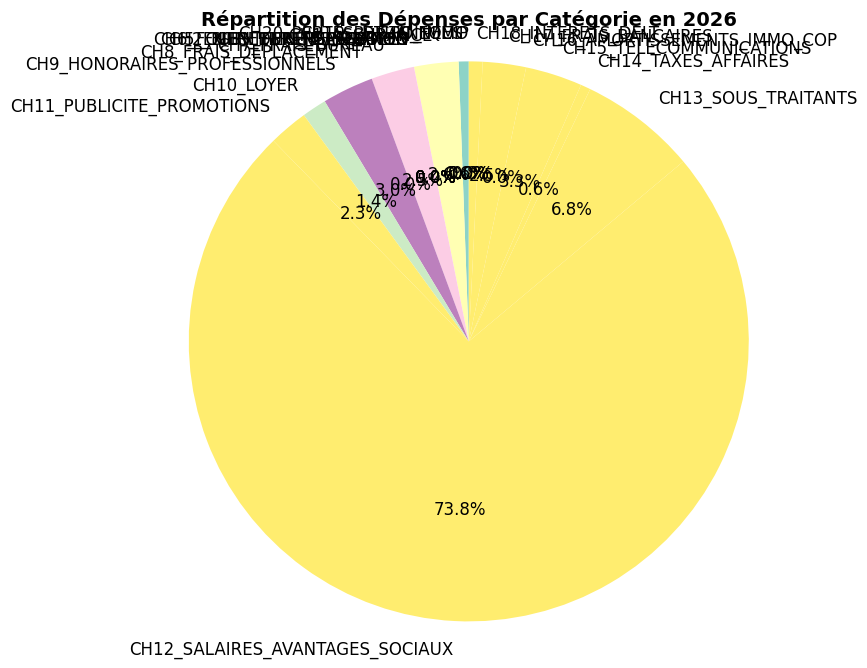

In [ ]:
import matplotlib.pyplot as plt

# pie chart of 2026 total expenses
plt.figure(figsize=(10, 8))

# Couleurs plus harmonieuses
colors = plt.cm.Set3(range(len(total_expenses_percentage_2026)))

plt.pie(
    total_expenses_percentage_2026, labels=total_expenses_percentage_2026.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    textprops={'fontsize': 12}
)

plt.title('Répartition des Dépenses par Catégorie en 2026', fontsize=14, fontweight='bold')

# Assurer que le pie chart est bien rond
plt.axis('equal')

plt.show()

###Le ratio salaire/revenu est satisfaisant s'il est compris entre 30% et 40%. Alosque celui de TVC22 est superieur a 70% ce qui est tres inconfortable pour la situation financiere de l entreprise.


 ##Etant en fin d'exercise, les decisions prises maintenant vont aider l' entreprise a se stabiliser et surtout etre viable sur le long terme

In [ ]:
X = df[["ANNEES"]]
y = df["Total_Income"]

model = LinearRegression()
model.fit(X, y)

future_years = np.array([[2027], [2028], [2029], [2030]])
forecast = model.predict(future_years)


future_df = pd.DataFrame({
    "ANNEES": future_years.flatten(),
    "R1_BINGO/NEVADA": 0,
    "FORECAST_REVENUE": forecast
})
print(future_df)
print(model.score(X, y))


   ANNEES  R1_BINGO/NEVADA  FORECAST_REVENUE
0    2027                0     389363.294545
1    2028                0     403724.558636
2    2029                0     418085.822727
3    2030                0     432447.086818
0.23532385451879356


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
  #Linear regression of expenses
  x = df[["ANNEES"]]
  y = df["Total_Expenses"]

  model = LinearRegression()
  model.fit(X, y)
  future_years = np.array([[2027], [2028], [2029], [2030]])
  forecast = model.predict(future_years)
  future_df = pd.DataFrame({
      "ANNEES": future_years.flatten(),
      "R1_BINGO/NEVADA": 0,
      "FORECAST_REVENUE": forecast
  })
  print(future_df)
  print(model.score(X, y))



   ANNEES  R1_BINGO/NEVADA  FORECAST_REVENUE
0    2027                0     382834.032727
1    2028                0     396135.582273
2    2029                0     409437.131818
3    2030                0     422738.681364
0.4891462582471272


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
#linear regression of profit
x = df[["ANNEES"]]
y = df["Profit"]

model = LinearRegression()
model.fit(X, y)
future_years = np.array([[2027], [2028], [2029], [2030]])
forecast = model.predict(future_years)
future_df = pd.DataFrame({
    "ANNEES": future_years.flatten(),
    "R1_BINGO/NEVADA": 0,
    "FORECAST_REVENUE": forecast
})
print(future_df)
print(model.score(X, y))

   ANNEES  R1_BINGO/NEVADA  FORECAST_REVENUE
0    2027                0       6529.261818
1    2028                0       7588.976364
2    2029                0       8648.690909
3    2030                0       9708.405455
0.0030618160202735556


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
#Random Forest Model
rf_tvc22 = RandomForestRegressor(n_estimators=100, random_state=42)
rf_tvc22.fit(df[['ANNEES']], df['Profit'])

print(rf_tvc22.feature_importances_)
print(rf_tvc22.score(df[['ANNEES']], df['Profit']))



[1.]
0.7877277703891671


In [ ]:
#seperates futures
x=df.drop(['Profit'], axis=1)
y=df['Profit']

In [ ]:
#split data into test and train
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)




In [ ]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [ ]:
# Evaluate the Random Forest model
mse_rf = mean_squared_error(y_test, y_pred)
r2_rf = r2_score(y_test, y_pred)

print(f"Random Forest Mean Squared Error (MSE): {mse_rf:.2f}")
print(f"Random Forest R-squared (R2 Score): {r2_rf:.2f}")

Random Forest Mean Squared Error (MSE): 5276061588.95
Random Forest R-squared (R2 Score): -0.78


In [ ]:
# Make predictions using the trained Random Forest model
y_pred_rf = model.predict(X_test)

# Print the first 5 predictions

print("Random Forest Predictions on the test set (first 5):")
print(y_pred_rf[:5])

Random Forest Predictions on the test set (first 5):
[-11003.2764 -21521.9328  24855.3416]


In [ ]:
#Model optimization
#Hyper parameter
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [ 300, 400],
    'max_depth': [ 100, 200],
    'min_samples_split': [ 5, 10, 15],
    'min_samples_leaf': [5, 10, 20]
}
grid_search = GridSearchCV(RandomForestRegressor(), param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(X_train, y_train)
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_
print("Best Hyperparameters:", best_params)
print("Best Model:", best_model)
print(best_model.score(X_test, y_test))


Best Hyperparameters: {'max_depth': 100, 'min_samples_leaf': 10, 'min_samples_split': 15, 'n_estimators': 400}
Best Model: RandomForestRegressor(max_depth=100, min_samples_leaf=10, min_samples_split=15,
                      n_estimators=400)
-0.02230529585382457


In [ ]:
#cross validation
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(best_model, X_train.to_frame(), y_train, cv=5, scoring='neg_mean_squared_error')
cv_mse = -cv_scores.mean()
print("Cross-Validation Mean Squared Error:", cv_mse)


Cross-Validation Mean Squared Error: 3659868531.4355164


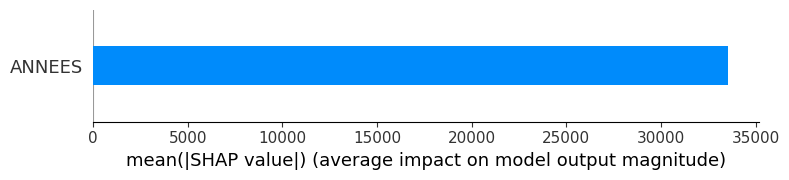

In [ ]:
#SHAP
import shap
shap.initjs()
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_train.to_frame())
shap.summary_plot(shap_values, X_train.to_frame(), plot_type="bar")


The Mean Squared Error (MSE) quantifies the average squared difference between the observed actual outcomes and the outcomes predicted by the model. A lower MSE indicates a better fit.

The R-squared (R2) score represents the proportion of the variance in the dependent variable that is predictable from the independent variable(s). It ranges from 0 to 1, where 1 indicates that the model explains all the variability of the response data around its mean, and 0 indicates that the model explains no variability.